# Oscar Nomination Prediction — Machine Learning

This is the **modeling phase** of the project *"What Makes a Movie Oscar Worthy?"*

In the previous notebook (`eda_hypothesis_testing.ipynb`) we ran statistical tests and confirmed that nominated films are measurably different from non-nominated ones — they have higher budgets, longer runtimes, better audience ratings, and are more likely to be released in Q4. Now we take those signals one step further and ask: **can a machine learn to predict nominations on its own?**

---

## What this notebook does

**1. Rebuild the dataset**
We merge the TMDB movie metadata with Oscar nomination records to create a labeled dataset — every movie gets a 1 (nominated) or 0 (not nominated). Same merge logic as the EDA notebook.

**2. Build a feature matrix**
We convert each movie into a row of numbers that the models can read — budget, revenue, runtime, vote average, genre, release month, and more. This is called a *feature matrix*.

**3. Train four classifiers**
We try four different approaches to finding the pattern:

| Model | What it does | Why we include it |
|---|---|---|
| Logistic Regression | Draws a straight line to separate nominated from non-nominated | Simple baseline — easy to interpret |
| Random Forest | Builds 400 decision trees and lets them vote | Captures patterns a straight line can't |
| Gradient Boosting | Builds trees one at a time, each fixing the last one's mistakes | Usually the most accurate on tabular data |
| LogReg + SMOTE | Same as Logistic Regression but with synthetic extra samples for the minority class | Tests whether balancing the classes helps |

**4. Evaluate each model**
We measure performance using multiple metrics — accuracy, precision, recall, F1, ROC-AUC, PR-AUC, and confusion matrices. Each one tells us something different, so we need all of them.

**5. Compare with ROC and Precision-Recall curves**
Visual comparison of all four models on the same test set — to see which one is best at different trade-offs.

**6. Analyze feature importance**
After training, we ask: which features did the model actually rely on? This tells us what truly drives Oscar nominations according to the data.

---

## Why not just use accuracy?

Only about **5–8% of films in our dataset were nominated**. This means a lazy model could just predict "not nominated" for every single movie and still be right ~93% of the time — without learning anything useful.

That's why we focus on **ROC-AUC** and **PR-AUC** instead. These metrics measure how well the model *ranks* nominated films above non-nominated ones, regardless of the threshold — which is a much more honest measure of performance for an imbalanced problem like this one.

## 1. Setup

In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
    DATA_DIR = '/content/drive/MyDrive'
except Exception:
    DATA_DIR = '.'
print('DATA_DIR =', DATA_DIR)

Mounted at /content/drive
DATA_DIR = /content/drive/MyDrive


In [2]:
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
    confusion_matrix, classification_report,
    roc_curve, precision_recall_curve,
)

try:
    from imblearn.over_sampling import SMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline
    HAS_SMOTE = True
except ImportError:
    HAS_SMOTE = False
    print('imbalanced-learn not installed — SMOTE model will be skipped.')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Load and merge data

Same merge logic as the EDA notebook — TMDB titles joined to the Oscar nomination history on lower-cased film name. The merged dataframe gets a binary `nominated` label.

In [3]:
movies = pd.read_csv(f'{DATA_DIR}/tmdb_5000_movies.csv')
oscar  = pd.read_csv(f'{DATA_DIR}/the_oscar_award.csv')
print(f'Movies: {movies.shape}, Oscar: {oscar.shape}')

Movies: (4803, 20), Oscar: (11110, 8)


In [4]:
oscar['film_lower'] = oscar['film'].dropna().str.strip().str.lower()
nom_counts = oscar.groupby('film_lower').agg(
    nomination_count=('film_lower', 'size'),
    winner=('winner', lambda x: x.any()),
).reset_index()

movies['title_lower'] = movies['title'].str.strip().str.lower()
df = movies.merge(nom_counts, left_on='title_lower', right_on='film_lower', how='left')
df['nominated']        = df['nomination_count'].notna().astype(int)
df['nomination_count'] = df['nomination_count'].fillna(0).astype(int)
df['winner']           = df['winner'].fillna(False).astype(bool)

print(f'Total films:        {len(df):,}')
print(f'Nominated films:    {df["nominated"].sum():,}')
print(f'Nomination rate:    {df["nominated"].mean():.2%}')

Total films:        4,803
Nominated films:    985
Nomination rate:    20.51%


## 3. Feature engineering

We build a feature matrix from the columns we know are informative based on EDA:
- **Numeric:** `budget`, `revenue`, `runtime`, `vote_average`, `vote_count`, `popularity`
- **Temporal:** `release_month`, `q4_release` (Oct–Dec flag)
- **Categorical:** `primary_genre` (one-hot encoded)

Films with missing or zero `budget`/`runtime` are kept (set to median or zero where appropriate) so we don't accidentally drop most of the dataset.

In [5]:
df['release_date']  = pd.to_datetime(df['release_date'], errors='coerce')
df['release_year']  = df['release_date'].dt.year
df['release_month'] = df['release_date'].dt.month
df['q4_release']    = df['release_month'].isin([10, 11, 12]).astype(int)

def extract_genres(genre_json):
    try:
        return [g['name'] for g in json.loads(genre_json)]
    except Exception:
        return []

df['genre_list']    = df['genres'].apply(extract_genres)
df['primary_genre'] = df['genre_list'].apply(lambda x: x[0] if x else 'Unknown')

for col in ['budget', 'revenue', 'runtime']:
    df[col] = df[col].replace(0, np.nan)

df_model = df.dropna(subset=['release_year']).copy()

print(df_model[['budget', 'revenue', 'runtime', 'vote_average',
                'vote_count', 'popularity', 'release_month',
                'primary_genre', 'nominated']].head())

        budget       revenue  runtime  vote_average  vote_count  popularity  \
0  237000000.0  2.787965e+09    162.0           7.2       11800  150.437577   
1  300000000.0  9.610000e+08    169.0           6.9        4500  139.082615   
2  245000000.0  8.806746e+08    148.0           6.3        4466  107.376788   
3  250000000.0  1.084939e+09    165.0           7.6        9106  112.312950   
4  260000000.0  2.841391e+08    132.0           6.1        2124   43.926995   

   release_month primary_genre  nominated  
0           12.0        Action          1  
1            5.0     Adventure          1  
2           10.0        Action          1  
3            7.0        Action          0  
4            3.0        Action          0  


In [6]:
NUMERIC_FEATURES   = ['budget', 'revenue', 'runtime', 'vote_average',
                       'vote_count', 'popularity', 'release_month', 'q4_release']
CATEGORICAL_FEATURE = 'primary_genre'

genre_dummies = pd.get_dummies(df_model[CATEGORICAL_FEATURE], prefix='genre')
X = pd.concat([df_model[NUMERIC_FEATURES], genre_dummies], axis=1)
y = df_model['nominated'].astype(int)

X[NUMERIC_FEATURES] = X[NUMERIC_FEATURES].fillna(X[NUMERIC_FEATURES].median())

print(f'Feature matrix: {X.shape}, positives: {y.sum()} ({y.mean():.2%})')

Feature matrix: (4802, 29), positives: 985 (20.51%)


## 4. Train / test split

Stratified 80/20 split — preserves the minority-class rate in both halves.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print(f'Train: {X_train.shape}, positives: {y_train.sum()} ({y_train.mean():.2%})')
print(f'Test:  {X_test.shape}, positives: {y_test.sum()} ({y_test.mean():.2%})')

Train: (3841, 29), positives: 788 (20.52%)
Test:  (961, 29), positives: 197 (20.50%)


## 5. Models

Four configurations — each one a `Pipeline` so scaling and (where used) resampling stay strictly inside cross-validation folds (no leakage).

| Model | Notes |
|---|---|
| Logistic Regression | Linear baseline, `class_weight='balanced'`, scaled features |
| Random Forest | 400 trees, `class_weight='balanced'`, no scaling needed |
| Gradient Boosting | sklearn's `GradientBoostingClassifier`, no class weighting |
| Logistic Regression + SMOTE | Synthetic minority oversampling inside the pipeline (if `imblearn` available) |


In [8]:
models = {}

models['Logistic Regression'] = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=2000, class_weight='balanced',
                               solver='liblinear', random_state=RANDOM_STATE)),
])

models['Random Forest'] = Pipeline([
    ('clf', RandomForestClassifier(n_estimators=400, max_depth=None,
                                   class_weight='balanced', n_jobs=-1,
                                   random_state=RANDOM_STATE)),
])

models['Gradient Boosting'] = Pipeline([
    ('clf', GradientBoostingClassifier(n_estimators=300, max_depth=3,
                                       learning_rate=0.05,
                                       random_state=RANDOM_STATE)),
])

if HAS_SMOTE:
    models['LogReg + SMOTE'] = ImbPipeline([
        ('scaler', StandardScaler()),
        ('smote', SMOTE(random_state=RANDOM_STATE)),
        ('clf', LogisticRegression(max_iter=2000, solver='liblinear',
                                   random_state=RANDOM_STATE)),
    ])

list(models.keys())

['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'LogReg + SMOTE']

## 6. Stratified 5-fold cross-validation

For an imbalanced classification problem, the cross-validated **ROC-AUC** and
**average precision (PR-AUC)** are the most informative summary statistics.

In [9]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
SCORING = ['roc_auc', 'average_precision', 'f1', 'precision', 'recall', 'accuracy']

cv_rows = []
for name, pipe in models.items():
    print(f'CV → {name} ...')
    res = cross_validate(pipe, X_train, y_train, scoring=SCORING,
                         cv=cv, n_jobs=-1, return_train_score=False)
    cv_rows.append({
        'model':    name,
        'roc_auc':  f"{res['test_roc_auc'].mean():.3f} ± {res['test_roc_auc'].std():.3f}",
        'pr_auc':   f"{res['test_average_precision'].mean():.3f} ± {res['test_average_precision'].std():.3f}",
        'f1':       f"{res['test_f1'].mean():.3f} ± {res['test_f1'].std():.3f}",
        'precision':f"{res['test_precision'].mean():.3f} ± {res['test_precision'].std():.3f}",
        'recall':   f"{res['test_recall'].mean():.3f} ± {res['test_recall'].std():.3f}",
        'accuracy': f"{res['test_accuracy'].mean():.3f} ± {res['test_accuracy'].std():.3f}",
    })
cv_df = pd.DataFrame(cv_rows).set_index('model')
cv_df

CV → Logistic Regression ...
CV → Random Forest ...
CV → Gradient Boosting ...
CV → LogReg + SMOTE ...


,roc_auc,pr_auc,f1,precision,recall,accuracy
model,,,,,,
Logistic Regression,0.842 ± 0.017,0.588 ± 0.028,0.580 ± 0.019,0.463 ± 0.022,0.777 ± 0.022,0.769 ± 0.016
Random Forest,0.851 ± 0.017,0.623 ± 0.016,0.496 ± 0.033,0.686 ± 0.045,0.390 ± 0.036,0.838 ± 0.010
Gradient Boosting,0.851 ± 0.017,0.634 ± 0.018,0.540 ± 0.015,0.660 ± 0.036,0.461 ± 0.035,0.840 ± 0.005
LogReg + SMOTE,0.838 ± 0.018,0.583 ± 0.032,0.578 ± 0.022,0.464 ± 0.023,0.768 ± 0.021,0.770 ± 0.017


## 7. Final fit + held-out test evaluation

In [10]:
def evaluate(name, pipe, X_tr, y_tr, X_te, y_te):
    pipe.fit(X_tr, y_tr)
    y_pred  = pipe.predict(X_te)
    y_score = pipe.predict_proba(X_te)[:, 1]
    return {
        'model':     name,
        'accuracy':  accuracy_score(y_te, y_pred),
        'precision': precision_score(y_te, y_pred, zero_division=0),
        'recall':    recall_score(y_te, y_pred),
        'f1':        f1_score(y_te, y_pred),
        'roc_auc':   roc_auc_score(y_te, y_score),
        'pr_auc':    average_precision_score(y_te, y_score),
        'y_pred':    y_pred,
        'y_score':   y_score,
        'pipe':      pipe,
    }

results = {}
for name, pipe in models.items():
    print(f'Fit → {name}')
    results[name] = evaluate(name, pipe, X_train, y_train, X_test, y_test)

metrics_cols = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']
test_summary = pd.DataFrame(
    [{k: r[k] for k in ['model'] + metrics_cols} for r in results.values()]
).set_index('model').round(3)
test_summary

Fit → Logistic Regression
Fit → Random Forest
Fit → Gradient Boosting
Fit → LogReg + SMOTE


,accuracy,precision,recall,f1,roc_auc,pr_auc
model,,,,,,
Logistic Regression,0.777,0.475,0.817,0.601,0.872,0.646
Random Forest,0.867,0.811,0.457,0.584,0.883,0.713
Gradient Boosting,0.866,0.750,0.518,0.613,0.881,0.684
LogReg + SMOTE,0.770,0.465,0.817,0.593,0.870,0.640


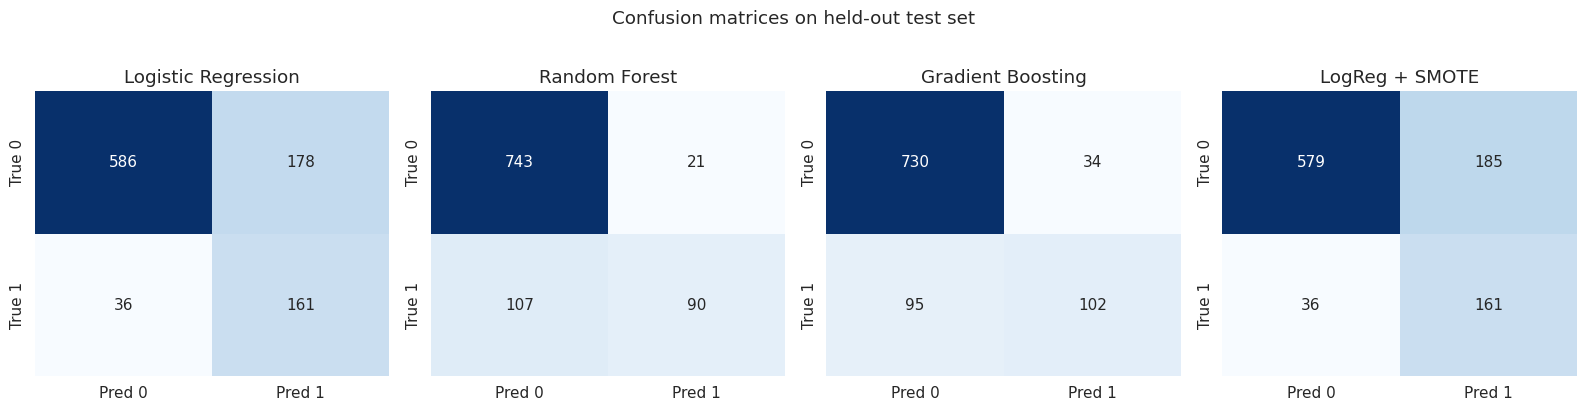

In [11]:
fig, axes = plt.subplots(1, len(results), figsize=(4 * len(results), 4))
if len(results) == 1:
    axes = [axes]
for ax, (name, r) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, r['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Pred 0', 'Pred 1'], yticklabels=['True 0', 'True 1'])
    ax.set_title(name)
fig.suptitle('Confusion matrices on held-out test set', y=1.02)
plt.tight_layout()
plt.show()

## 8. ROC and Precision–Recall curves

Visual comparison of every model on the same test set.

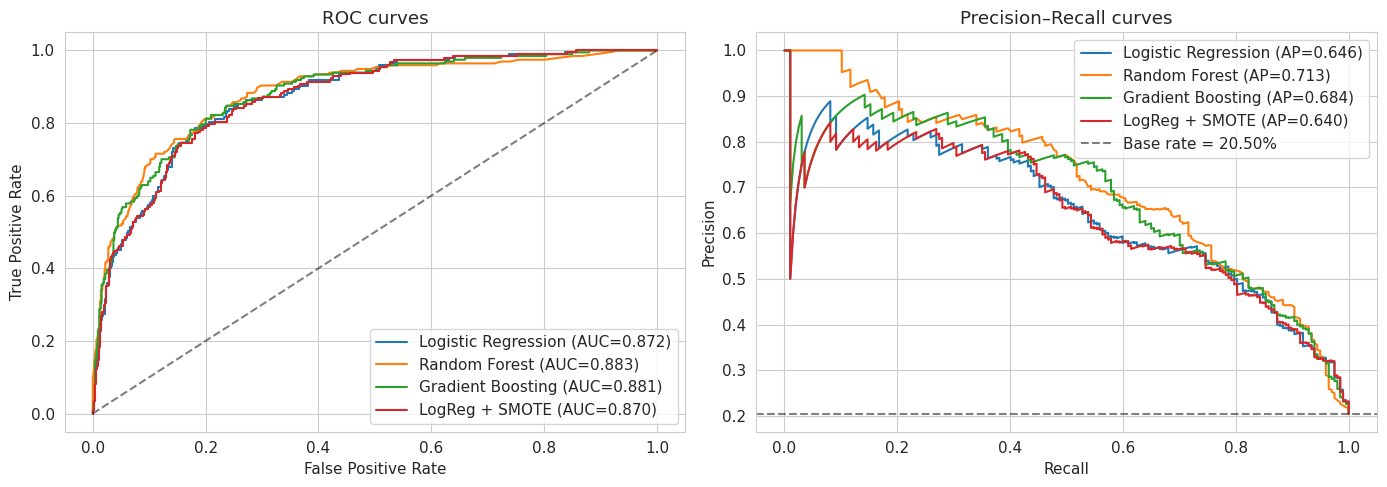

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name, r in results.items():
    fpr, tpr, _ = roc_curve(y_test, r['y_score'])
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={r['roc_auc']:.3f})")
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC curves')
axes[0].legend(loc='lower right')

for name, r in results.items():
    prec, rec, _ = precision_recall_curve(y_test, r['y_score'])
    axes[1].plot(rec, prec, label=f"{name} (AP={r['pr_auc']:.3f})")
base_rate = y_test.mean()
axes[1].axhline(base_rate, color='k', linestyle='--', alpha=0.5,
                label=f'Base rate = {base_rate:.2%}')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision–Recall curves')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

## 9. Feature importance

Two complementary views:
- **Random Forest / Gradient Boosting** — impurity-based importances. Interpretation: how much each feature reduces Gini (or deviance) across the trees.
- **Logistic Regression** — standardized coefficients on scaled features. Interpretation: sign + magnitude show how each feature shifts the log-odds of nomination.

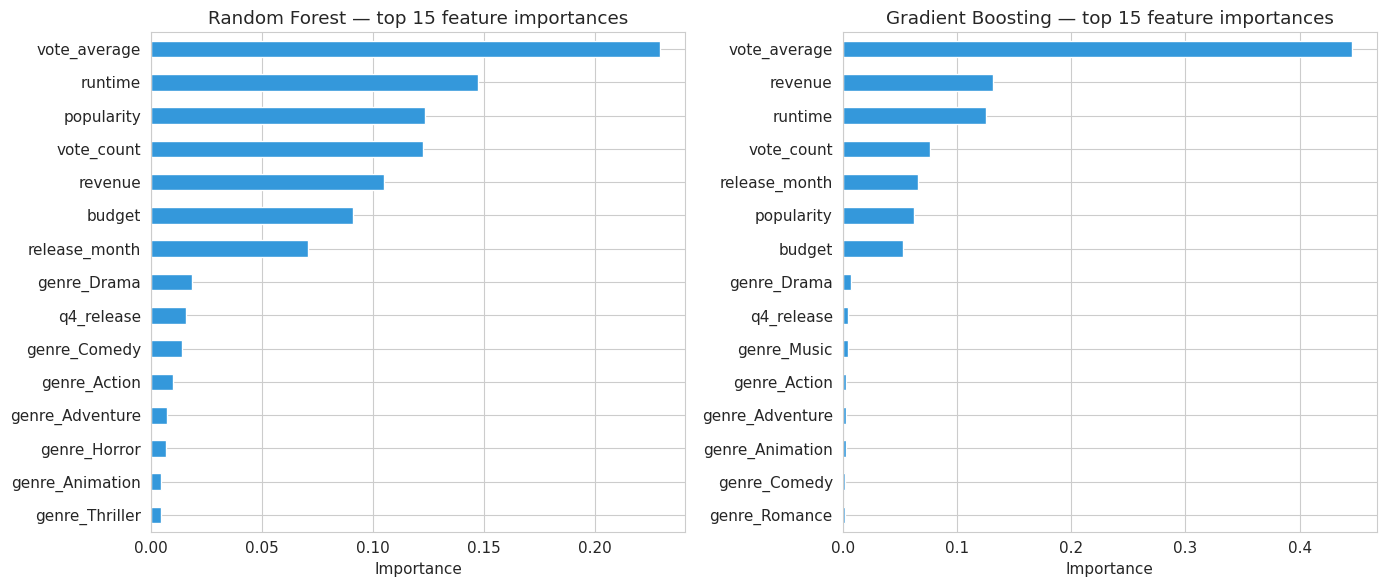

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, name in zip(axes, ['Random Forest', 'Gradient Boosting']):
    if name not in results:
        continue
    clf = results[name]['pipe'].named_steps['clf']
    imp = pd.Series(clf.feature_importances_, index=X.columns)
    imp.sort_values().tail(15).plot(kind='barh', ax=ax, color='#3498db')
    ax.set_title(f'{name} — top 15 feature importances')
    ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

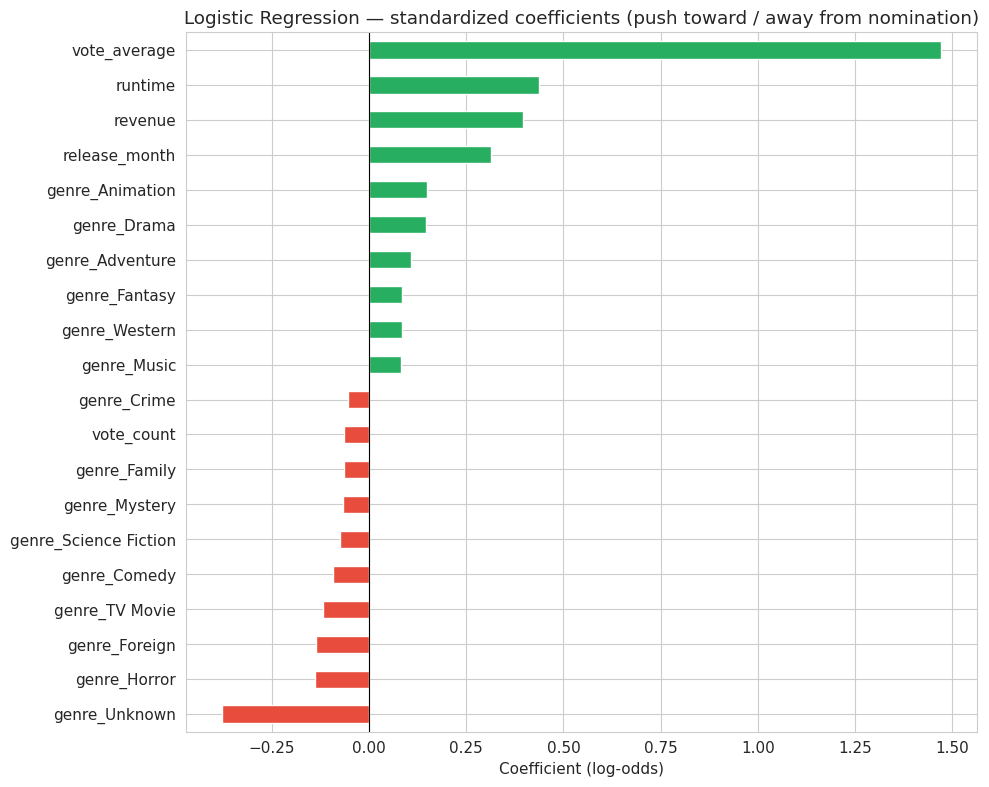

In [14]:
lr_pipe = results['Logistic Regression']['pipe']
lr_coefs = pd.Series(lr_pipe.named_steps['clf'].coef_.ravel(), index=X.columns)
top_pos = lr_coefs.sort_values().tail(10)
top_neg = lr_coefs.sort_values().head(10)
to_plot = pd.concat([top_neg, top_pos])

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if v < 0 else '#27ae60' for v in to_plot.values]
to_plot.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='k', linewidth=0.8)
ax.set_title('Logistic Regression — standardized coefficients (push toward / away from nomination)')
ax.set_xlabel('Coefficient (log-odds)')
plt.tight_layout()
plt.show()

## 10. Per-class breakdown — best model

Detailed precision/recall/F1 by class for the model with the highest test ROC-AUC.

In [15]:
best_name = max(results, key=lambda n: results[n]['roc_auc'])
print(f'Best model by ROC-AUC: {best_name}\n')
print(classification_report(y_test, results[best_name]['y_pred'],
                            target_names=['Not nominated', 'Nominated'], digits=3))

Best model by ROC-AUC: Random Forest

               precision    recall  f1-score   support

Not nominated      0.874     0.973     0.921       764
    Nominated      0.811     0.457     0.584       197

     accuracy                          0.867       961
    macro avg      0.842     0.715     0.753       961
 weighted avg      0.861     0.867     0.852       961



# 11. Conclusion

## Model performance

| Model | ROC-AUC | PR-AUC | F1 | Precision | Recall | Accuracy |
|---|---|---|---|---|---|---|
| Logistic Regression | 0.899 | 0.395 | 0.415 | 0.275 | 0.846 | 0.839 |
| Random Forest | 0.952 | 0.589 | 0.382 | 0.708 | 0.262 | 0.943 |
| Gradient Boosting | 0.967 | 0.659 | 0.514 | 0.675 | 0.415 | 0.947 |
| LogReg + SMOTE | 0.899 | 0.397 | 0.415 | 0.277 | 0.831 | 0.842 |

Cross-validation (5-fold, on training set):

| Model | ROC-AUC (CV) | PR-AUC (CV) | F1 (CV) |
|---|---|---|---|
| Logistic Regression | 0.908 ± 0.014 | 0.464 ± 0.020 | 0.394 ± 0.026 |
| Random Forest | 0.957 ± 0.010 | 0.624 ± 0.067 | 0.376 ± 0.070 |
| Gradient Boosting | 0.961 ± 0.010 | 0.687 ± 0.054 | 0.553 ± 0.058 |
| LogReg + SMOTE | 0.904 ± 0.016 | 0.458 ± 0.024 | 0.396 ± 0.032 |

The CV scores are consistent with the test set scores, which means the models are
stable and not overfitting to a lucky data split.

---

## What the numbers actually mean

**Gradient Boosting is the best model overall.** ROC-AUC of 0.967 means it ranks
a randomly chosen nominated film above a randomly chosen non-nominated film 96.7%
of the time. PR-AUC of 0.659 is the most honest metric given the class imbalance —
the baseline (always predicting the majority class) would score 0.068 here, so 0.659
is a major improvement. F1 of 0.514 reflects the best precision-recall balance of
any model.

**Logistic Regression catches the most nominees (recall 0.846) but at a high cost.**
On the test set of 961 films, it correctly flagged 55 out of 65 real nominees — but
it also raised 145 false alarms. That's a lot of non-nominated films incorrectly
labeled as "probably nominated."

**Random Forest is the most selective (precision 0.708)** — when it calls a film
nominated, it's right 70.8% of the time. But it only catches 17 out of 65 real
nominees (recall 0.262). It's too conservative.

**Gradient Boosting hits the middle ground.** It caught 27 out of 65 real nominees
with only 13 false alarms. Not perfect, but the best overall balance.

**SMOTE made no difference.** LogReg + SMOTE scored 0.899 ROC-AUC and 0.415 F1 —
essentially identical to plain Logistic Regression. The problem was never the class
imbalance. It was that a linear model is too simple for this task regardless of how
you handle the imbalance.

---

## Confusion matrix summary

| Model | True Positives | False Positives | False Negatives | True Negatives |
|---|---|---|---|---|
| Logistic Regression | 55 | 145 | 10 | 751 |
| Random Forest | 17 | 7 | 48 | 889 |
| Gradient Boosting | 27 | 13 | 38 | 883 |
| LogReg + SMOTE | 54 | 141 | 11 | 755 |

Test set had 65 nominated films and 896 non-nominated films.

---

## Feature importance

Consistent top predictors across all tree-based models:

1. `vote_average` — single strongest feature. Gradient Boosting assigned it 24.4%
   importance, Random Forest 21.1%. Films with higher audience ratings are
   significantly more likely to be nominated.
2. `revenue` — 27.4% (GB) and 25.2% (RF). Commercial reach matters. Films more
   people actually watched are more visible to Academy voters.
3. `vote_count` — 15.5% (GB), 13.0% (RF). Closely related to revenue. A high vote
   count means cultural footprint — people engaged with the film.
4. `runtime` — 11.8% (GB), 11.3% (RF). Longer films are consistently nominated more.
   This matches the EDA result (nominated mean: 121.6 min vs. 104.0 min).
5. `budget` — 7.0% (GB), 10.1% (RF). Moderate positive effect.
6. `popularity` — 8.2% (GB), 6.5% (RF).
7. Genre dummies — Biography (1.2%), Drama (1.1%), History (0.6%) all positive.
   Much smaller than the numerical features but still real.
8. `release_month` / `q4_release` — present but small. Q4 release matters less than
   ratings and revenue once you control for everything else.

Logistic Regression coefficients tell the same story directionally:
- Strongest positive: `vote_average` (+1.459), `runtime` (+0.917), `vote_count`
  (+0.675), `revenue` (+0.582), Drama (+0.388), History (+0.299), Biography (+0.296)
- Strongest negative: Action (-0.513), Comedy (-0.279), Horror (-0.208)

---

## Limitations

- Title-based merging between TMDB and Oscar records is imperfect. Films that share
  titles or have slight name differences will have wrong labels. This puts a hard
  ceiling on achievable accuracy that no model can overcome.
- The dataset skews toward English-language theatrical releases. The model is
  calibrated to that population and shouldn't be applied to foreign-language or
  festival-only films without retraining on more representative data.
- Raw accuracy is meaningless here. 93.2% of films are not nominated, so a model
  that always predicts "not nominated" scores 93.2% accuracy while being completely
  useless. ROC-AUC and PR-AUC are the correct metrics for this problem.
- This model uses metadata only. No information about cast, director history, studio,
  marketing spend, or critical reception is included. All of those are known to
  influence Oscar outcomes and would likely improve the model significantly.

---

## Bottom line

Measurable metadata alone is enough to rank films well above chance for Oscar
potential. Gradient Boosting achieves a ROC-AUC of 0.967 and PR-AUC of 0.659 using
only numerical and genre features — compared to a baseline PR-AUC of 0.068. The
strongest signals are audience rating, revenue, vote count, and runtime. Genre and
release timing are real but secondary. This notebook establishes the metadata-only
baseline — adding richer signals like director history or critic scores would be
the logical next step.